In [1]:
import numpy as np
import random
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing
import matplotlib.pyplot as plt

In [2]:
# ----------------------------
# 0) Utilities
# ----------------------------
def _rng(seed):
    return np.random.default_rng(seed)

def pad_to_pmax(a_time_p, p_max):
    """Pad [T, p_true] -> [T, p_max] with zeros."""
    T, p = a_time_p.shape
    out = np.zeros((T, p_max), dtype=a_time_p.dtype)
    out[:, :p] = a_time_p
    return out

In [3]:
# ----------------------------
# 1) Smooth coefficient schedules (Task 1)
# Each returns a_time with shape [T, p_true]
# ----------------------------

# Shared lag structure: gives each lag a distinct identity
_BASE_FREQS   = np.array([1/150, 1/200, 1/180, 1/220, 1/170, 1/190, 1/160, 1/210, 1/175, 1/195])
_BASE_AMPS    = np.array([0.35, 0.25, 0.20, 0.15, 0.12, 0.10, 0.09, 0.08, 0.07, 0.06])
_BASE_OFFSETS = np.array([0.6, -0.5, 0.3, -0.2, 0.15, -0.1, 0.08, -0.06, 0.05, -0.04])
_BASE_PHASES  = np.array([k * np.pi / 4 for k in range(10)])

def _lag_params(p, l1_target=0.85):
    """Return (freqs, amps, offsets, phases) for p lags.
    
    Scales so that the worst-case L1 norm sum(|offset_k| + |amp_k|)
    stays at l1_target, with headroom for the random jitter each
    schedule function applies. This keeps the AR process stable by
    construction — no post-hoc clipping of coefficients needed.
    """
    freqs   = _BASE_FREQS[:p].copy()
    amps    = _BASE_AMPS[:p].copy()
    offsets = _BASE_OFFSETS[:p].copy()
    phases  = _BASE_PHASES[:p].copy()

    # Worst-case L1: every lag at its peak, with ~20% jitter headroom
    jitter_headroom = 1.20
    raw_l1 = np.sum(np.abs(offsets) + np.abs(amps)) * jitter_headroom

    scale = l1_target / raw_l1 if raw_l1 > 0 else 1.0

    return freqs, amps * scale, offsets * scale, phases


def schedule_sinusoid(T, p, rng, freq_jitter=0.15, amp_jitter=0.15):
    """Sinusoidal with distinct per-lag freq/amp/offset + small random jitter."""
    t = np.arange(T)
    freqs, amps, offsets, phases = _lag_params(p)
    
    # Add small random jitter to keep stochasticity across samples
    freqs  *= (1 + rng.uniform(-freq_jitter, freq_jitter, size=p))
    amps   *= (1 + rng.uniform(-amp_jitter, amp_jitter, size=p))
    offsets *= (1 + rng.uniform(-0.1, 0.1, size=p))
    phases += rng.uniform(-np.pi/8, np.pi/8, size=p)
    
    a = np.zeros((T, p), dtype=np.float32)
    for k in range(p):
        if k % 2 == 0:
            a[:, k] = offsets[k] + amps[k] * np.sin(2*np.pi*freqs[k]*t + phases[k])
        else:
            a[:, k] = offsets[k] + amps[k] * np.cos(2*np.pi*freqs[k]*t + phases[k])
    return a


def schedule_fourier(T, p, rng, M=3, amp_jitter=0.2):
    """Fourier series with distinct base freq per lag + decaying harmonics."""
    t = np.arange(T)
    freqs, amps, offsets, phases = _lag_params(p)
    freqs *= (1 + rng.uniform(-0.15, 0.15, size=p))
    
    a = np.zeros((T, p), dtype=np.float32)
    for k in range(p):
        ak = offsets[k] * np.ones(T)
        for m in range(1, M+1):
            harm_amp = amps[k] / (m**1.2) * (1 + rng.uniform(-amp_jitter, amp_jitter))
            phi = phases[k] * m + rng.uniform(-np.pi/6, np.pi/6)
            if (k + m) % 2 == 0:
                ak += harm_amp * np.sin(2*np.pi*(m*freqs[k])*t + phi)
            else:
                ak += harm_amp * np.cos(2*np.pi*(m*freqs[k])*t + phi)
        a[:, k] = ak
    return a


def schedule_quasiperiodic(T, p, rng, freq_jitter=0.15):
    """Two incommensurate frequencies per lag, with distinct structure."""
    t = np.arange(T)
    freqs, amps, offsets, phases = _lag_params(p)
    
    # Second set of frequencies (shifted)
    freqs2 = np.roll(freqs, 1) * 1.3 * (1 + rng.uniform(-freq_jitter, freq_jitter, size=p))
    amps2 = amps * rng.uniform(0.4, 0.8, size=p)
    phases2 = phases + rng.uniform(np.pi/4, np.pi/2, size=p)
    
    freqs *= (1 + rng.uniform(-freq_jitter, freq_jitter, size=p))
    
    a = np.zeros((T, p), dtype=np.float32)
    for k in range(p):
        a[:, k] = (offsets[k] 
                    + amps[k] * np.sin(2*np.pi*freqs[k]*t + phases[k])
                    + amps2[k] * np.cos(2*np.pi*freqs2[k]*t + phases2[k]))
    return a


def schedule_polynomial_drift(T, p, rng, degree=3, coef_jitter=0.3):
    """Polynomial drift with distinct offset/scale per lag."""
    tn = np.linspace(-1, 1, T)
    _, amps, offsets, _ = _lag_params(p)
    
    a = np.zeros((T, p), dtype=np.float32)
    for k in range(p):
        # Start from the structured offset
        ak = offsets[k] * np.ones(T)
        # Add polynomial variation scaled by lag amplitude
        betas = rng.normal(0, amps[k] * (1 + rng.uniform(-coef_jitter, coef_jitter)), size=degree+1)
        betas[0] = 0  # offset already handled
        for d in range(1, degree+1):
            ak += betas[d] * (tn**d)
        a[:, k] = ak
    return a


def schedule_logistic_transition(T, p, rng):
    """Logistic transition between two distinct levels per lag."""
    tau_range = (T/10, T/4)
    t = np.arange(T)
    _, amps, offsets, _ = _lag_params(p)
    
    a = np.zeros((T, p), dtype=np.float32)
    for k in range(p):
        # Transition between offset +/- amp (distinct per lag)
        alo = offsets[k] - amps[k] * (1 + rng.uniform(-0.2, 0.2))
        ahi = offsets[k] + amps[k] * (1 + rng.uniform(-0.2, 0.2))
        t0  = rng.integers(int(0.2*T), int(0.8*T))
        tau = rng.uniform(tau_range[0], tau_range[1])
        s = 1.0 / (1.0 + np.exp(-(t - t0)/tau))
        a[:, k] = alo + (ahi - alo) * s
    return a


def schedule_multi_sigmoid(T, p, rng, J=3):
    """Multiple sigmoid steps around lag-specific baselines."""
    tau_range = (T/20, T/8)
    t = np.arange(T)
    _, amps, offsets, _ = _lag_params(p)
    
    a = np.zeros((T, p), dtype=np.float32)
    for k in range(p):
        ak = offsets[k] * np.ones(T)
        t0s = np.sort(rng.integers(int(0.1*T), int(0.9*T), size=J))
        for j in range(J):
            delta = rng.normal(0, amps[k] * 0.5)
            tau = rng.uniform(tau_range[0], tau_range[1])
            s = 1.0 / (1.0 + np.exp(-(t - t0s[j])/tau))
            ak += delta * s
        a[:, k] = ak
    return a


def schedule_gaussian_bumps(T, p, rng, J=4):
    """Gaussian bumps around lag-specific baselines."""
    width_range = (T/10, T/5)
    t = np.arange(T)
    _, amps, offsets, _ = _lag_params(p)
    
    a = np.zeros((T, p), dtype=np.float32)
    for k in range(p):
        ak = offsets[k] * np.ones(T)
        for _ in range(J):
            mu = rng.uniform(0.1*T, 0.9*T)
            sig = rng.uniform(width_range[0], width_range[1])
            c = rng.uniform(-amps[k], amps[k])
            ak += c * np.exp(-0.5 * ((t - mu)/sig)**2)
        a[:, k] = ak
    return a


def schedule_smooth_random(T, p, rng):
    """GP-like smooth random around lag-specific baselines."""
    smooth_sigma = T/10
    _, amps, offsets, _ = _lag_params(p)
    
    a = np.zeros((T, p), dtype=np.float32)
    freqs = np.fft.rfftfreq(T)
    H = np.exp(-2*(np.pi**2) * (smooth_sigma**2) * (freqs**2))
    for k in range(p):
        w = rng.normal(0, 1, size=T)
        W = np.fft.rfft(w)
        sm = np.fft.irfft(W * H, n=T)
        sm = sm / (np.std(sm) + 1e-8)
        a[:, k] = (offsets[k] + amps[k] * sm).astype(np.float32)
    return a


# Registry of families you can benchmark
SCHEDULES = {
    "sinusoid": schedule_sinusoid,
    "fourier": schedule_fourier,
    "quasiperiodic": schedule_quasiperiodic,
    "poly_drift": schedule_polynomial_drift,
    "logistic": schedule_logistic_transition,
    "multi_sigmoid": schedule_multi_sigmoid,
    "gaussian_bumps": schedule_gaussian_bumps,
    "smooth_random": schedule_smooth_random,
}

In [4]:
# ----------------------------
# 2) Generic TVAR simulator (Task 1 core) with Soft Power Clamping + Hard Rejection
# ----------------------------
def simulate_tvar(a_time, noise_std=0.3, seed=0, burn_in=300,
                  P0=0.5, W=40, power_control=True,
                  divergence_threshold=1e6):
    """
    Simulate a TVAR process with soft power clamping and hard rejection safety net:
        x_t = a(t)^T [x_{t-1}, ..., x_{t-p}] + eps_t

    During simulation, if window power exceeds P0, the current sample is scaled
    by clip(sqrt(P0/power), 0.8, 1.2) to gently steer power back toward the target.
    After simulation, a final hard check rejects if power still exceeds P0.
    """
    rng = _rng(seed)
    T, p = a_time.shape

    T_full = T + int(burn_in)
    x_full = np.zeros(T_full, dtype=np.float64)
    eps = rng.normal(0.0, noise_std, size=T_full)

    x_full[:p] = eps[:p]

    for t in range(p, T_full):
        tau = t - int(burn_in)
        if tau < 0:
            a_t = a_time[0]
        else:
            a_t = a_time[min(tau, T - 1)]

        lags = x_full[t-p:t][::-1]
        x_full[t] = np.dot(a_t, lags) + eps[t]

        # Early divergence check — fail fast instead of letting values blow up
        if abs(x_full[t]) > divergence_threshold:
            return None, None

        # Soft power clamping (matches the working tvar() function)
        if power_control and t >= W - 1:
            window = x_full[t - W + 1:t + 1]
            current_power = np.mean(window ** 2)
            if current_power > 0:
                s = np.clip(np.sqrt(P0 / current_power), 0.8, 1.2)
                x_full[t] *= s

    # Drop burn-in (safe cast now — divergent runs already returned None)
    x = x_full[int(burn_in):].astype(np.float32)

    # Hard rejection safety net: only check full W-sized windows
    # (matches soft clamping which only activates at t >= W-1)
    if power_control and len(x) >= W:
        x2 = x ** 2
        cumsum = np.concatenate([[0.0], np.cumsum(x2)])
        ends = np.arange(W, len(x) + 1)
        starts = ends - W
        power = (cumsum[ends] - cumsum[starts]) / W
        if np.any(power > P0):
            return None, None

    return x, a_time

In [5]:
# ----------------------------
# 3) One-sample generator + dataset wrapper (Task 2 groundwork)
# ----------------------------

def generate_one_tvar_sample(
    T=10_000,
    p_max=6,
    schedule_name="sinusoid",
    noise_std=0.3,
    seed=0,
    l1_cap=0.95,
    P0=0.5,
    W=40,
    power_control=True,
    p_true=None,  # If provided, use this p; otherwise random
    p_candidates=None,
    max_retries=10000,  # Maximum resampling attempts
):
    rng = _rng(seed)
    if p_candidates is None:
        p_candidates = np.array([2, 3, 4, 5, 6], dtype=int)
    
    # Use provided p_true or randomly select
    if p_true is None:
        p_true = int(rng.choice(p_candidates))
    else:
        p_true = int(p_true)

    # Retry loop: resample until we get a valid sample
    current_seed = seed
    for attempt in range(max_retries):
        # Use a fresh rng for coefficient schedule each attempt
        attempt_rng = _rng(current_seed)
        
        # coefficient schedule for true p
        a_tp = SCHEDULES[schedule_name](T=T, p=p_true, rng=attempt_rng)

        # simulate signal with power control (rejection-based)
        x, a_actual = simulate_tvar(
            a_tp, noise_std=noise_std, seed=current_seed+123,
            P0=P0, W=W, power_control=power_control
        )

        # If valid sample (not rejected), break out
        if x is not None:
            break
        
        # Increment seed for next attempt
        current_seed += 1
    else:
        raise RuntimeError(f"Failed to generate valid sample after {max_retries} retries for schedule '{schedule_name}', p_true={p_true}")

    # pad coeffs to p_max for consistent storage
    a_t = pad_to_pmax(a_actual.astype(np.float32), p_max)

    meta = {
        "T": T,
        "p_max": p_max,
        "p_true": p_true,
        "schedule": schedule_name,
        "noise_std": float(noise_std),
        "seed": int(current_seed),  # Record the seed that actually worked
        "l1_cap": float(l1_cap),
        "P0": float(P0),
        "W": int(W),
        "power_control": power_control,
        "p_candidates": list(p_candidates),
        "retries": attempt,  # Number of retries needed
    }
    return x, a_t, meta


def _generate_sample_worker(args):
    """
    Worker function for parallel sample generation.
    Takes a dict of arguments and returns (idx, x, a_t, meta, cid, ns).
    """
    idx = args["idx"]
    T = args["T"]
    p_max = args["p_max"]
    cname = args["cname"]
    ns = args["ns"]
    s = args["s"]
    P0 = args["P0"]
    W = args["W"]
    power_control = args["power_control"]
    p_true_val = args["p_true_val"]
    p_candidates = args["p_candidates"]
    cid = args["cid"]
    
    x, a_t, meta = generate_one_tvar_sample(
        T=T, p_max=p_max, schedule_name=cname, noise_std=ns, seed=s,
        P0=P0, W=W, power_control=power_control,
        p_true=p_true_val, p_candidates=p_candidates,
    )
    
    return idx, x, a_t, meta, cid, ns


def generate_dataset(
    n_per_class=10,
    classes=None,
    T=1000,
    noise_range=(0.1, 0.6),
    seed=0,
    dtype=np.float32,
    P0=0.5,
    W=40,
    power_control=True,
    p_candidates=None,
    balanced_p=True,  # If True, balance samples across p_candidates
    n_workers=None,  # Number of parallel workers (None = CPU count)
):
    
    p_max = 10
    
    if p_candidates is None:
        p_candidates = np.array([2, 3, 4, 5, 6], dtype=int)
    else:
        p_candidates = np.array(p_candidates, dtype=int)

    if classes is None:
        classes = list(SCHEDULES.keys())

    if n_workers is None:
        n_workers = multiprocessing.cpu_count()

    rng = _rng(seed)
    N = n_per_class * len(classes)

    X = np.zeros((N, T), dtype=dtype)
    A = np.zeros((N, T, p_max), dtype=dtype)
    p_true_arr = np.zeros((N,), dtype=np.int32)
    class_id = np.zeros((N,), dtype=np.int32)
    noise_std = np.zeros((N,), dtype=dtype)

    class_names = list(classes)
    
    # Precompute p assignments if balanced
    n_p = len(p_candidates)
    if balanced_p:
        n_per_p = n_per_class // n_p
        remainder = n_per_class % n_p
        # Create balanced p assignments for one class
        p_assignments = []
        for i, p in enumerate(p_candidates):
            count = n_per_p + (1 if i < remainder else 0)
            p_assignments.extend([p] * count)
    
    # Build all task arguments
    tasks = []
    idx = 0
    for cid, cname in enumerate(class_names):
        # Shuffle p assignments for this class
        if balanced_p:
            class_p_assignments = rng.permutation(p_assignments)
        
        for i in range(n_per_class):
            s = int(rng.integers(0, 2**31 - 1))
            ns = float(rng.uniform(noise_range[0], noise_range[1]))
            
            # Determine p_true
            if balanced_p:
                p_true_val = int(class_p_assignments[i])
            else:
                p_true_val = None  # Let generate_one_tvar_sample pick randomly
            
            tasks.append({
                "idx": idx,
                "T": T,
                "p_max": p_max,
                "cname": cname,
                "ns": ns,
                "s": s,
                "P0": P0,
                "W": W,
                "power_control": power_control,
                "p_true_val": p_true_val,
                "p_candidates": list(p_candidates),
                "cid": cid,
            })
            idx += 1
    
    metas = [None] * N
    
    # Parallel execution
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(_generate_sample_worker, task): task["idx"] for task in tasks}
        
        with tqdm(total=N, desc=f"Generating samples ({n_workers} workers)") as pbar:
            for future in as_completed(futures):
                idx, x, a_t, meta, cid, ns = future.result()
                X[idx] = x.astype(dtype)
                A[idx] = a_t.astype(dtype)
                p_true_arr[idx] = meta["p_true"]
                class_id[idx] = cid
                noise_std[idx] = ns
                metas[idx] = meta
                pbar.update(1)

    dataset = {
        "X": X,
        "A": A,
        "p_true": p_true_arr,
        "class_id": class_id,
        "class_names": np.array(class_names),
        "noise_std": noise_std,
        "meta": metas,  # Python list of dicts; fine for notebook use
    }
    return dataset


def generate_dataset_sequential(
    n_per_class=10,
    classes=None,
    T=1000,
    noise_range=(0.1, 0.6),
    seed=0,
    dtype=np.float32,
    P0=0.5,
    W=40,
    power_control=True,
    p_candidates=None,
    balanced_p=True,
):
    """Original sequential version for comparison/fallback."""
    
    p_max = 10
    
    if p_candidates is None:
        p_candidates = np.array([2, 3, 4, 5, 6], dtype=int)
    else:
        p_candidates = np.array(p_candidates, dtype=int)

    if classes is None:
        classes = list(SCHEDULES.keys())

    rng = _rng(seed)
    N = n_per_class * len(classes)

    X = np.zeros((N, T), dtype=dtype)
    A = np.zeros((N, T, p_max), dtype=dtype)
    p_true_arr = np.zeros((N,), dtype=np.int32)
    class_id = np.zeros((N,), dtype=np.int32)
    noise_std = np.zeros((N,), dtype=dtype)

    class_names = list(classes)
    
    n_p = len(p_candidates)
    if balanced_p:
        n_per_p = n_per_class // n_p
        remainder = n_per_class % n_p
        p_assignments = []
        for i, p in enumerate(p_candidates):
            count = n_per_p + (1 if i < remainder else 0)
            p_assignments.extend([p] * count)
    
    metas = []
    idx = 0
    pbar = tqdm(total=N, desc="Generating samples (sequential)")
    for cid, cname in enumerate(class_names):
        if balanced_p:
            class_p_assignments = rng.permutation(p_assignments)
        
        for i in range(n_per_class):
            s = int(rng.integers(0, 2**31 - 1))
            ns = float(rng.uniform(noise_range[0], noise_range[1]))
            
            if balanced_p:
                p_true_val = int(class_p_assignments[i])
            else:
                p_true_val = None
            
            x, a_t, meta = generate_one_tvar_sample(
                T=T, p_max=p_max, schedule_name=cname, noise_std=ns, seed=s,
                P0=P0, W=W, power_control=power_control,
                p_true=p_true_val, p_candidates=p_candidates,
            )
            X[idx] = x.astype(dtype)
            A[idx] = a_t.astype(dtype)
            p_true_arr[idx] = meta["p_true"]
            class_id[idx] = cid
            noise_std[idx] = ns
            metas.append(meta)
            idx += 1
            pbar.update(1)
    
    pbar.close()

    dataset = {
        "X": X,
        "A": A,
        "p_true": p_true_arr,
        "class_id": class_id,
        "class_names": np.array(class_names),
        "noise_std": noise_std,
        "meta": metas,
    }
    return dataset


def save_dataset_npz(path, dataset):
    # Save large arrays in npz; meta dicts as object array
    np.savez_compressed(
        path,
        X=dataset["X"],
        A=dataset["A"],
        p_true=dataset["p_true"],
        class_id=dataset["class_id"],
        class_names=dataset["class_names"],
        noise_std=dataset["noise_std"],
        meta=np.array(dataset["meta"], dtype=object),
    )

def load_dataset_npz(path):
    d = np.load(path, allow_pickle=True)
    return {
        "X": d["X"],
        "A": d["A"],
        "p_true": d["p_true"],
        "class_id": d["class_id"],
        "class_names": d["class_names"],
        "noise_std": d["noise_std"],
        "meta": list(d["meta"]),
    }

In [6]:
# ----------------------------
# 4) PINN Processor - load dataset for model training
# ----------------------------

def pinn_processor(npz_path, p_min=1):
    """
    Load a saved TVAR benchmark dataset and return arrays ready for training.
    
    Argsp_max
    ----
    npz_path : str
        Path to the .npz file saved by save_dataset_npz().
    p_min : int
        Minimum AR order used when generating the dataset. 
        Used to compute 0-indexed class labels for cross entropy.
    
    Returns
    -------
    X : array, shape [N, T]
        Time series samples.
    coeffs : array, shape [N, T, p_max]
        Time-varying AR coefficients (actual, after power control).
    p_true : array, shape [N]
        True AR order for each sample, 0-indexed (p_true_raw - p_min) for cross entropy.
    """
    dataset = load_dataset_npz(npz_path)
    
    X = dataset["X"]              # [N, T]
    coeffs = dataset["A"]         # [N, T, p_max]
    p_true_raw = dataset["p_true"]  # [N], actual AR orders (e.g., 1, 2, 4, 6)
    
    # Convert p_true to 0-indexed labels for cross entropy loss
    # Map unique p values to consecutive indices
    unique_p = np.sort(np.unique(p_true_raw))
    p_to_idx = {int(p): i for i, p in enumerate(unique_p)}
    p_true = np.array([p_to_idx[int(p)] for p in p_true_raw], dtype=np.int64)
    
    return X, coeffs, p_true



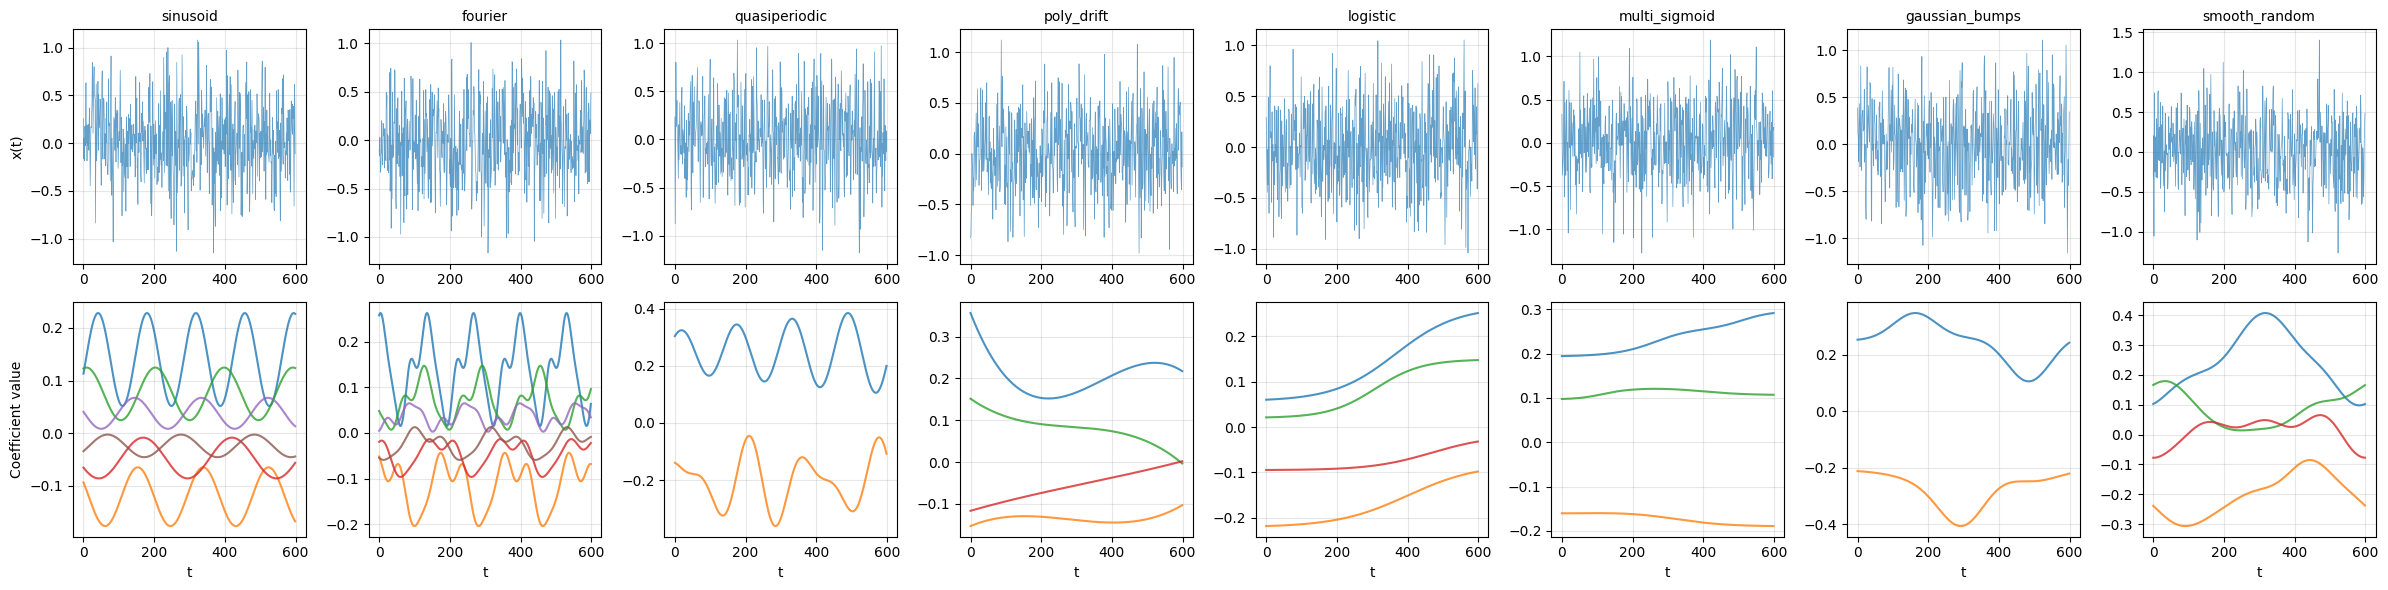

In [7]:
# Plot one example of each schedule type: signal (top row) + coefficients (bottom row)
schedule_names = list(SCHEDULES.keys())

fig, axes = plt.subplots(2, 8, figsize=(24, 6))

for i, schedule_name in enumerate(schedule_names):
    x, a_t, meta = generate_one_tvar_sample(
        T=600, p_max=10,
        schedule_name=schedule_name,
        noise_std=0.3,
        seed=np.random.randint(0, 2**31 - 1)
    )
    
    p_true = meta["p_true"]
    
    # Top row: signal
    ax_sig = axes[0, i]
    ax_sig.plot(x, alpha=0.7, linewidth=0.5)
    ax_sig.set_title(schedule_name, fontsize=10)
    ax_sig.grid(True, alpha=0.3)
    if i == 0:
        ax_sig.set_ylabel("x(t)")
    
    # Bottom row: coefficients
    ax_coef = axes[1, i]
    for k in range(p_true):
        ax_coef.plot(a_t[:, k], label=f"a{k+1}(t)", alpha=0.8)
    ax_coef.grid(True, alpha=0.3)
    if i == 0:
        ax_coef.set_ylabel("Coefficient value")
    ax_coef.set_xlabel("t")

plt.tight_layout()
plt.show()

In [8]:
# 8 families
classes = list(SCHEDULES.keys())

# small pilot: 10 per family => 80 samples total
pilot = generate_dataset(
    n_per_class=125000, 
    classes=classes,
    T=600,
    noise_range=(0.2, 0.5),
    seed=123,
    dtype=np.float32
)

print("X:", pilot["X"].shape, "A:", pilot["A"].shape)
print("class_names:", pilot["class_names"])
print("p_true distribution:", np.unique(pilot["p_true"], return_counts=True))

Generating samples (64 workers): 100%|██████████| 1000000/1000000 [03:12<00:00, 5190.09it/s]


X: (1000000, 600) A: (1000000, 600, 10)
class_names: ['sinusoid' 'fourier' 'quasiperiodic' 'poly_drift' 'logistic'
 'multi_sigmoid' 'gaussian_bumps' 'smooth_random']
p_true distribution: (array([2, 3, 4, 5, 6], dtype=int32), array([200000, 200000, 200000, 200000, 200000]))


In [9]:
save_dataset_npz("train_data.npz", pilot)